# Step 4. 다변량 HMM 레짐 감지

기존 프로젝트는 **VIX 수준 1개 변수로 2-state HMM**을 사용했습니다.  
이를 **5개 변수로 확장한 다변량 HMM**으로 업그레이드하여 레짐 감지 정밀도를 높입니다.

| 입력 변수 | 리스크 채널 | 기존 대비 |
|----------|------------|----------|
| VIX_level | 주식 시장 변동성 | 기존 유일한 입력 |
| VIX_contango | 변동성 기간구조 | **신규** |
| HY_spread | 신용 시장 스트레스 | **신규** |
| yield_curve | 거시 경기 사이클 | **신규** |
| Cu_Au_ratio_chg | 실물 경제 모멘텀 | **신규** |

In [1]:
# ============================================================
# 라이브러리 및 데이터 로드
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

DATA_DIR = os.path.join(os.getcwd(), 'data')
IMG_DIR  = os.path.join(os.getcwd(), 'images')

df_reg = pd.read_csv(os.path.join(DATA_DIR, 'df_reg_v2.csv'),
                     index_col=0, parse_dates=True)
print(f'df_reg_v2: {df_reg.shape}')

df_reg_v2: (1045, 34)


## 4-1. HMM 입력 준비 + BIC 기반 모델 선택

5개 변수를 표준화(StandardScaler)한 후, n_components = 2, 3, 4에 대해  
**BIC(Bayesian Information Criterion)**를 비교하여 최적 상태 수를 결정합니다.

In [2]:
# ============================================================
# HMM 입력 변수 선택 + 표준화
# ============================================================

# 5개 리스크 채널 변수
HMM_FEATURES = ['VIX_level', 'VIX_contango', 'HY_spread', 'yield_curve', 'Cu_Au_ratio_chg']

X_raw = df_reg[HMM_FEATURES].dropna()
print(f'HMM 입력: {X_raw.shape}  ({X_raw.shape[0]}일 x {X_raw.shape[1]}변수)')

# 표준화 (HMM은 변수 스케일에 민감)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'\n표준화 후 평균: {X_scaled.mean(axis=0).round(6)}')
print(f'표준화 후 표준편차: {X_scaled.std(axis=0).round(6)}')

HMM 입력: (1045, 5)  (1045일 x 5변수)

표준화 후 평균: [ 0. -0.  0.  0.  0.]
표준화 후 표준편차: [1. 1. 1. 1. 1.]


In [3]:
# ============================================================
# BIC 기반 최적 상태 수 선택
# ============================================================

# BIC = -2 * log_likelihood + k * log(n)
#   k: 파라미터 수, n: 관측치 수
#   BIC가 낮을수록 좋은 모델 (복잡도 페널티 포함)

bic_results = []

for n_states in [2, 3, 4]:
    # 여러 시드로 반복 → 최적 수렴 선택
    best_score = -np.inf
    best_model = None

    for seed in range(10):  # 10번 시도하여 최고 log-likelihood 선택
        model = GaussianHMM(
            n_components=n_states,
            covariance_type='full',    # 변수 간 상관관계 포착
            n_iter=500,
            random_state=seed,
            tol=1e-4,
        )
        model.fit(X_scaled)
        score = model.score(X_scaled)  # log-likelihood
        if score > best_score:
            best_score = score
            best_model = model

    # BIC 수동 계산
    n = X_scaled.shape[0]
    d = X_scaled.shape[1]
    # 파라미터 수: 전이행렬 + 평균 + 공분산
    k_params = (n_states * (n_states - 1)     # 전이 행렬
                + n_states * d                  # 평균 벡터
                + n_states * d * (d + 1) // 2)  # 공분산 행렬 (대칭)
    bic = -2 * best_score + k_params * np.log(n)

    bic_results.append({
        'n_states': n_states,
        'log_likelihood': best_score,
        'k_params': k_params,
        'BIC': bic,
        'model': best_model,
    })
    print(f'  n={n_states}: LL={best_score:,.1f}  |  k={k_params}  |  BIC={bic:,.1f}')

# 최적 모델 선택 (BIC 최소)
best_idx = np.argmin([r['BIC'] for r in bic_results])
best_n = bic_results[best_idx]['n_states']
hmm_best = bic_results[best_idx]['model']

print(f'\n=== 최적 모델: n_states = {best_n} (BIC 최소) ===')

Model is not converging.  Current: -4817.401282007731 is not greater than -4817.401281484954. Delta is -5.227775545790792e-07


  n=2: LL=-4,817.4  |  k=42  |  BIC=9,926.8


Model is not converging.  Current: -4085.0724087423137 is not greater than -4085.072404312525. Delta is -4.429788532434031e-06


  n=3: LL=-4,075.6  |  k=66  |  BIC=8,610.0


  n=4: LL=-3,397.5  |  k=92  |  BIC=7,434.5

=== 최적 모델: n_states = 4 (BIC 최소) ===


## 4-2. 레짐 분류 + 라벨 정렬

VIX 평균이 낮은 순서대로 레짐을 정렬합니다:  
- 레짐 0 = Risk-On (안정기)  
- 레짐 1 = Transition (전환기)  
- 레짐 2 = Risk-Off (위기기)  

2-state 모델이 선택된 경우 레짐 0 = 안정, 레짐 1 = 위기로 분류합니다.

In [4]:
# ============================================================
# 레짐 분류 + 라벨 정렬
# ============================================================

# 레짐 예측
regimes_raw = hmm_best.predict(X_scaled)

# 각 레짐의 원래 스케일 평균값 복원
regime_means_scaled = hmm_best.means_
regime_means_orig = scaler.inverse_transform(regime_means_scaled)
regime_means_df = pd.DataFrame(regime_means_orig, columns=HMM_FEATURES)

# VIX_level 평균 기준으로 오름차순 정렬 (낮은 VIX = 안정)
order = regime_means_df['VIX_level'].argsort().values
label_map = {old: new for new, old in enumerate(order)}

# 라벨 재매핑
regimes = np.array([label_map[r] for r in regimes_raw])

# 레짐별 이름
n_regimes = hmm_best.n_components
if n_regimes == 2:
    regime_names = {0: 'Risk-On (안정)', 1: 'Risk-Off (위기)'}
elif n_regimes == 3:
    regime_names = {0: 'Risk-On (안정)', 1: 'Transition (전환)', 2: 'Risk-Off (위기)'}
else:
    regime_names = {i: f'Regime {i}' for i in range(n_regimes)}

# DataFrame에 추가
df_regime = X_raw.copy()
df_regime['regime'] = regimes
df_regime['regime_name'] = [regime_names[r] for r in regimes]

# 레짐별 통계
print(f'=== {n_regimes}-State HMM 레짐 분류 결과 ===')
for r in sorted(regime_names.keys()):
    mask = regimes == r
    n_days = mask.sum()
    pct = n_days / len(regimes) * 100
    avg_vix = X_raw.loc[X_raw.index[mask], 'VIX_level'].mean()
    avg_hy  = X_raw.loc[X_raw.index[mask], 'HY_spread'].mean()
    avg_yc  = X_raw.loc[X_raw.index[mask], 'yield_curve'].mean()
    print(f'  {regime_names[r]:25s}: {n_days:4d}일 ({pct:5.1f}%)  '
          f'| VIX={avg_vix:.1f}  HY={avg_hy:.2f}  YC={avg_yc:.2f}')

=== 4-State HMM 레짐 분류 결과 ===
  Regime 0                 :  281일 ( 26.9%)  | VIX=14.1  HY=3.56  YC=-0.49
  Regime 1                 :  273일 ( 26.1%)  | VIX=16.9  HY=2.89  YC=0.44
  Regime 2                 :  270일 ( 25.8%)  | VIX=22.2  HY=4.68  YC=-0.48
  Regime 3                 :  221일 ( 21.1%)  | VIX=24.9  HY=3.68  YC=0.28


In [5]:
# ============================================================
# 전이 확률 행렬 (재정렬된 라벨 기준)
# ============================================================

# 전이 행렬 재정렬
transmat_reordered = hmm_best.transmat_[order][:, order]

print('=== 전이 확률 행렬 ===')
trans_df = pd.DataFrame(
    transmat_reordered,
    index=[regime_names[i] for i in range(n_regimes)],
    columns=[regime_names[i] for i in range(n_regimes)]
)
print(trans_df.round(4))

# 해석
print(f'\n주요 전이 확률:')
if n_regimes >= 2:
    print(f'  안정 유지: {transmat_reordered[0, 0]:.1%}')
    print(f'  위기 유지: {transmat_reordered[-1, -1]:.1%}')
    print(f'  안정 -> 위기 방향: {transmat_reordered[0, -1]:.2%}')
    print(f'  위기 -> 안정 방향: {transmat_reordered[-1, 0]:.2%}')

=== 전이 확률 행렬 ===
          Regime 0  Regime 1  Regime 2  Regime 3
Regime 0    0.9929    0.0000    0.0036    0.0036
Regime 1    0.0000    0.9774    0.0000    0.0226
Regime 2    0.0074    0.0000    0.9926    0.0000
Regime 3    0.0000    0.0277    0.0045    0.9678

주요 전이 확률:
  안정 유지: 99.3%
  위기 유지: 96.8%
  안정 -> 위기 방향: 0.36%
  위기 -> 안정 방향: 0.00%


## 4-3. 레짐 타임라인 시각화

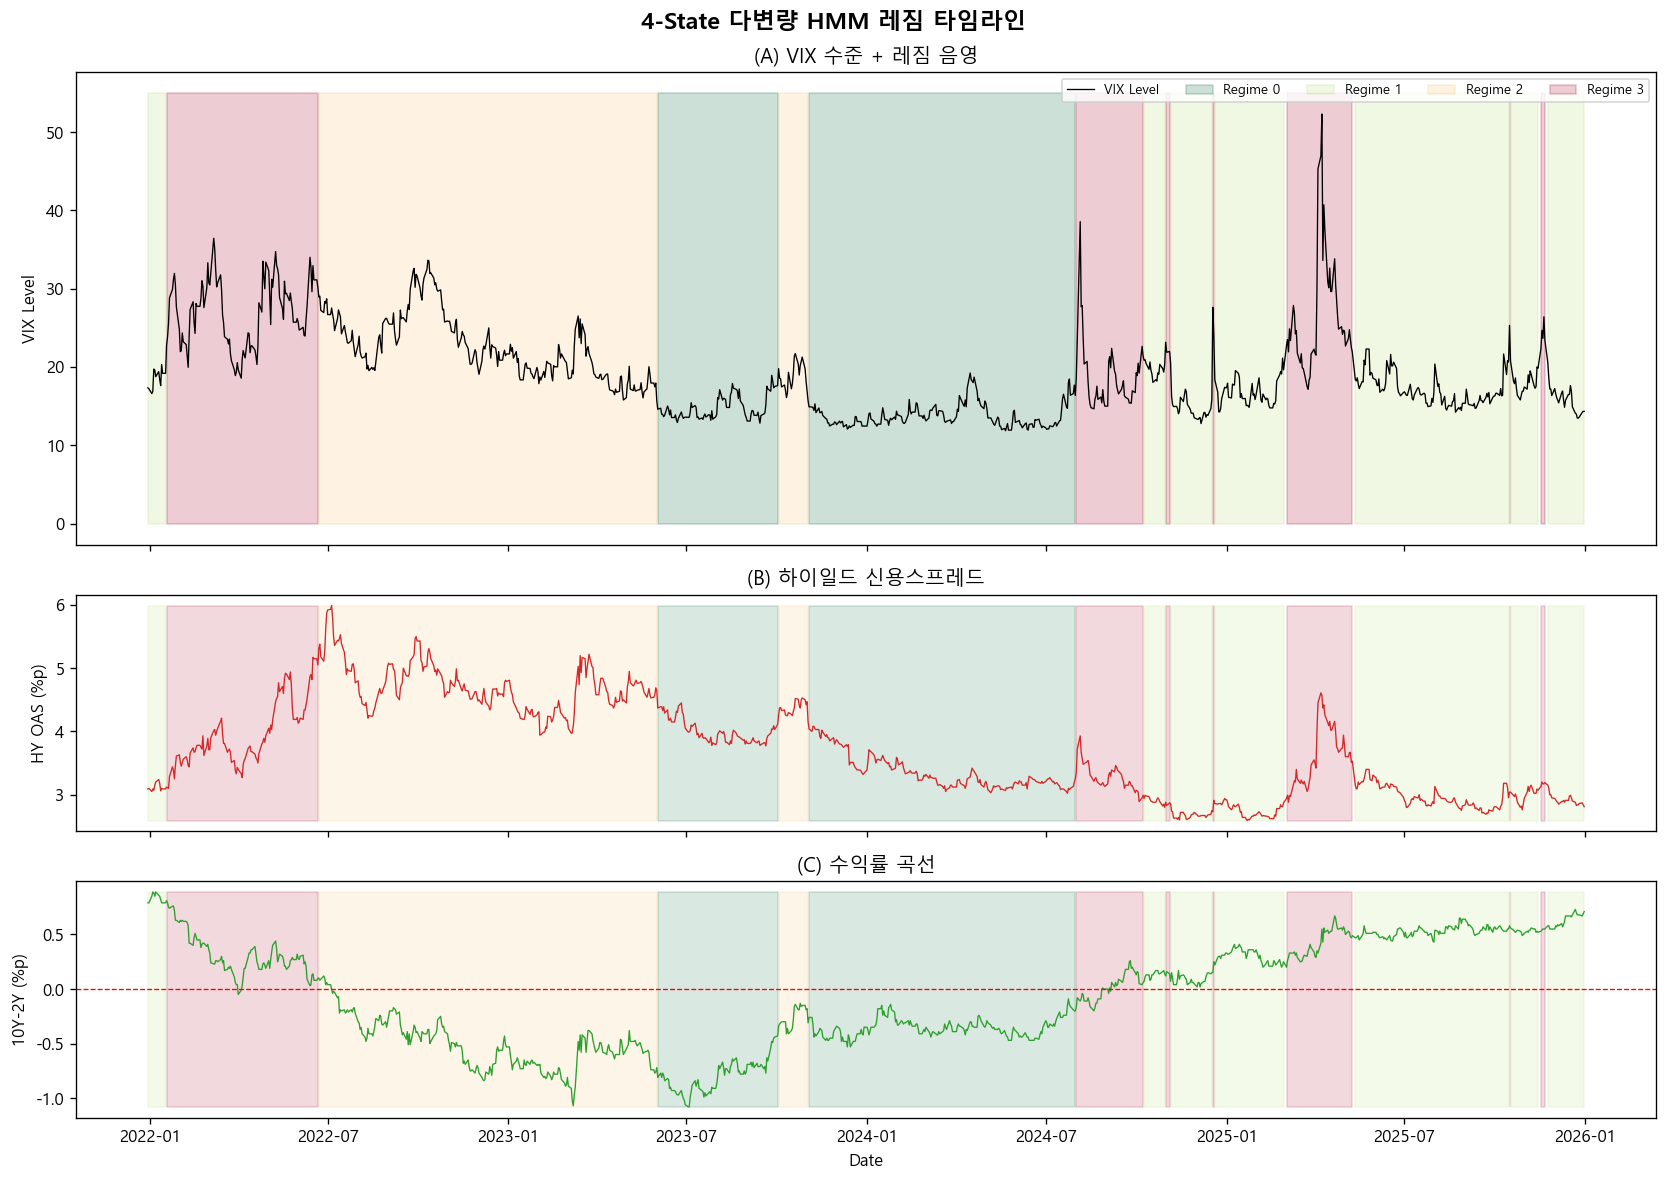

저장: images/hmm_01_regime_timeline.png


In [6]:
# ============================================================
# 레짐 타임라인 시각화
# ============================================================

# 레짐별 색상
if n_regimes == 2:
    regime_colors = {0: '#2ca02c', 1: '#d62728'}
elif n_regimes == 3:
    regime_colors = {0: '#2ca02c', 1: '#ff7f0e', 2: '#d62728'}
else:
    cmap = plt.cm.RdYlGn_r
    regime_colors = {i: cmap(i / (n_regimes - 1)) for i in range(n_regimes)}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1, 1]})
fig.suptitle(f'{n_regimes}-State 다변량 HMM 레짐 타임라인', fontsize=14, fontweight='bold')

# (A) VIX 수준 + 레짐 음영
ax = axes[0]
ax.plot(df_regime.index, df_regime['VIX_level'], color='black', linewidth=0.8, label='VIX Level')
for r in sorted(regime_colors.keys()):
    mask = df_regime['regime'] == r
    ax.fill_between(df_regime.index, 0, df_regime['VIX_level'].max() * 1.05,
                    where=mask, color=regime_colors[r], alpha=0.2, label=regime_names[r])
ax.set_ylabel('VIX Level')
ax.set_title('(A) VIX 수준 + 레짐 음영')
ax.legend(loc='upper right', fontsize=8, ncol=n_regimes + 1)

# (B) HY 스프레드
ax = axes[1]
ax.plot(df_regime.index, df_regime['HY_spread'], color='#d62728', linewidth=0.8)
for r in sorted(regime_colors.keys()):
    mask = df_regime['regime'] == r
    ax.fill_between(df_regime.index, df_regime['HY_spread'].min(), df_regime['HY_spread'].max(),
                    where=mask, color=regime_colors[r], alpha=0.15)
ax.set_ylabel('HY OAS (%p)')
ax.set_title('(B) 하이일드 신용스프레드')

# (C) 수익률 곡선
ax = axes[2]
ax.plot(df_regime.index, df_regime['yield_curve'], color='#2ca02c', linewidth=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
for r in sorted(regime_colors.keys()):
    mask = df_regime['regime'] == r
    ax.fill_between(df_regime.index, df_regime['yield_curve'].min(), df_regime['yield_curve'].max(),
                    where=mask, color=regime_colors[r], alpha=0.15)
ax.set_ylabel('10Y-2Y (%p)')
ax.set_title('(C) 수익률 곡선')
ax.set_xlabel('Date')

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'hmm_01_regime_timeline.png'), bbox_inches='tight')
plt.show()
print('저장: images/hmm_01_regime_timeline.png')

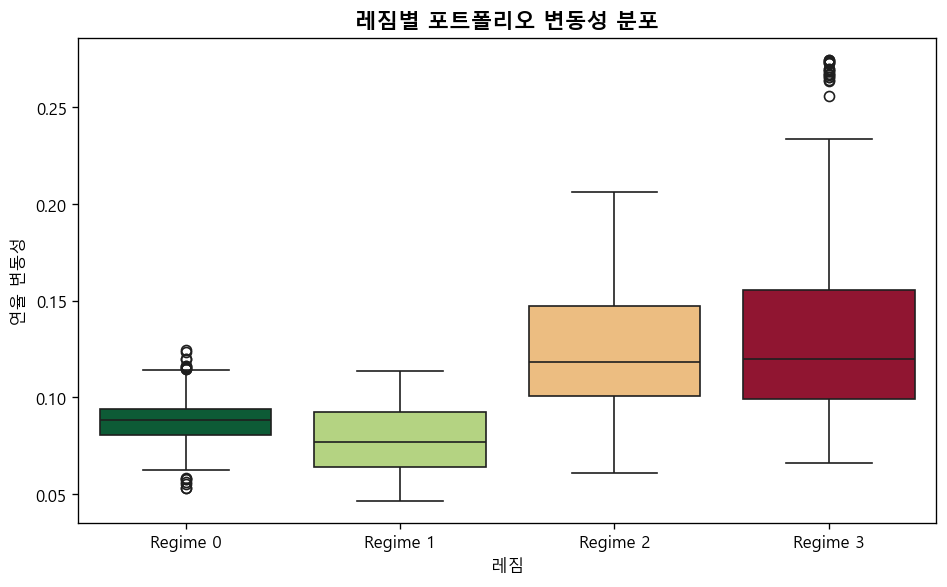

저장: images/hmm_02_regime_volatility.png


In [7]:
# ============================================================
# 레짐별 포트폴리오 변동성 분포 비교
# ============================================================

# rv_neutral 연결
df_regime['rv_neutral'] = df_reg.loc[df_regime.index, 'rv_neutral']

fig, ax = plt.subplots(figsize=(8, 5))
palette = [regime_colors[r] for r in sorted(regime_colors.keys())]
sns.boxplot(data=df_regime, x='regime_name', y='rv_neutral',
            order=[regime_names[r] for r in sorted(regime_names.keys())],
            palette=palette, ax=ax)
ax.set_title('레짐별 포트폴리오 변동성 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('레짐')
ax.set_ylabel('연율 변동성')

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'hmm_02_regime_volatility.png'), bbox_inches='tight')
plt.show()
print('저장: images/hmm_02_regime_volatility.png')

In [8]:
# ============================================================
# regime_history.csv 저장
# ============================================================

save_cols = ['VIX_level', 'VIX_contango', 'HY_spread',
             'yield_curve', 'Cu_Au_ratio_chg', 'regime', 'regime_name']
save_path = os.path.join(DATA_DIR, 'regime_history.csv')
df_regime[save_cols].to_csv(save_path)

print(f'저장: {save_path}')
print(f'Shape: {df_regime[save_cols].shape}')
print(f'기간: {df_regime.index[0].date()} ~ {df_regime.index[-1].date()}')
print(f'\n레짐 분포:')
print(df_regime['regime_name'].value_counts().to_string())

저장: C:\Users\gorhk\DA_Portfolio\01_Daily_Project\PJ12_Asset_Simulater\PJ12_v2_AltData\data\regime_history.csv
Shape: (1045, 7)
기간: 2021-12-30 ~ 2025-12-31

레짐 분포:
regime_name
Regime 0    281
Regime 1    273
Regime 2    270
Regime 3    221
